# **Social Media Usage and Emotional Well-Being**
#### DS 209 - Data Visualization || Group 2 || Final Exploratory Visualization


**Introduction:** With social media platforms such as Facebook, Instagram, TikTok, and Twitter becoming integral to our daily lives for communication, networking, and information sharing, it's essential to examine their impact on mental health . This project aims to investigate the relationship between social media usage and emotional well being, exploring how interactions on these platforms affect user’s mental health. Providing users with a way to explore how social media usage affects emotional well being through interactive dashboards and graph displays could help users develop healthier social media habits.

# **1. Import Libraries**

In [5]:
# importing libaries
import pandas as pd
import numpy as np
import altair as alt
import seaborn as sns
import matplotlib.pyplot as plt

# **2. Load Data**

In [6]:
# loading data
from google.colab import files
files.upload()

data= pd.read_csv('/content/social_media_data.csv')

Saving social_media_data.csv to social_media_data.csv


# **3. Data Exploration and Cleaning**

In [7]:
print(data.info())
print()

print(data.isnull().sum())
print()

null_userID = data[data['User_ID'].isnull()]
display(null_userID)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1249 entries, 0 to 1248
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   User_ID                     1248 non-null   object 
 1   Age                         1249 non-null   object 
 2   Gender                      1248 non-null   object 
 3   Platform                    1248 non-null   object 
 4   Daily_Usage_Time (minutes)  1248 non-null   float64
 5   Posts_Per_Day               1248 non-null   float64
 6   Likes_Received_Per_Day      1248 non-null   float64
 7   Comments_Received_Per_Day   1248 non-null   float64
 8   Messages_Sent_Per_Day       1248 non-null   float64
 9   Dominant_Emotion            1248 non-null   object 
dtypes: float64(5), object(5)
memory usage: 97.7+ KB
None

User_ID                       1
Age                           0
Gender                        1
Platform                      1
Daily_Usage_Time (minu

,User_ID,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion
1195,NaN,27,Non-binary,Facebook,55.0,1.0,9.0,2.0,11.0,Anxiety


In [8]:
# giving null userID a random user ID
null_userID = data[data['User_ID'].isnull()]

for index in null_userID.index:
  new_userID = np.random.randint(1,2000)

  # make sure the user id have not been used
  while new_userID in data['User_ID'].values:
    new_userID = np.random.randint(1,2000)

  # assessing the new user id
  data.at[index, 'User_ID'] = new_userID

# checking to see if implementation worked
# data[data['User_ID'].isnull()]
data = data.dropna()
print(data.isnull().sum())

User_ID                       0
Age                           0
Gender                        0
Platform                      0
Daily_Usage_Time (minutes)    0
Posts_Per_Day                 0
Likes_Received_Per_Day        0
Comments_Received_Per_Day     0
Messages_Sent_Per_Day         0
Dominant_Emotion              0
dtype: int64


In [9]:
for column in data.columns:
  unique_values = data[column].unique()
  print(f'Column: {column}')
  print([f'Unique values: {unique_values}'])

# getting rid of new line
data.replace(r'\n', '', regex = True, inplace = True)

Column: User_ID
["Unique values: ['1' '2' '3' ... '999' '1000' 1892]"]
Column: Age
["Unique values: ['25' '30' '22' '28' '33' '21' '27' '24' '29' '31' '23' '26' '34' '35'\n '32' 'Male' 'Female' 'Non-binary']"]
Column: Gender
["Unique values: ['Female' 'Male' 'Non-binary' '27' '24' '29' '33' '31' '22' '25' '28' '30'\n '23' '34' '26' '35' '21' '32' 'Marie']"]
Column: Platform
["Unique values: ['Instagram' 'Twitter' 'Facebook' 'LinkedIn' 'Whatsapp' 'Telegram'\n 'Snapchat']"]
Column: Daily_Usage_Time (minutes)
['Unique values: [120.  90.  60. 200.  45. 150.  85. 110.  55. 170.  75.  95.  65. 180.\n 100.  40. 125.  50. 140. 105. 190.  70.  80. 160. 145. 130. 115. 175.\n 165. 155.  72.  52.  30.]']
Column: Posts_Per_Day
['Unique values: [ 3.  5.  2.  8.  1.  4.  6.  7. 10.]']
Column: Likes_Received_Per_Day
['Unique values: [ 45.  20.  15. 100.   5.  60.  30.  25.  10.  80.  35.  12.  90.  40.\n  55.  33.   8.  70.  28.  11.  95.  18.   9.  85.  38.   6.  13.  75.\n  27.  88.  22.  78.  29.  

In [10]:
# switching values in age and gender
swapped_rows = data[(data['Age'].apply(lambda x: isinstance(x, str))) &
                    (data['Gender'].apply(lambda x: isinstance(x, int) or x.isdigit()))]


data.loc[swapped_rows.index, ['Age', 'Gender']] = data.loc[swapped_rows.index, ['Gender', 'Age']].values

# changing "Marie" to Male

data['Gender'].replace('Marie', 'Male', inplace = True)
# print(data['Gender'].unique())

# checking to see if changes applied
for column in data.columns:
  unique_values = data[column].unique()
  print(f'Column: {column}')
  print([f'Unique values: {unique_values}'])

Column: User_ID
["Unique values: ['1' '2' '3' ... '999' '1000' 1892]"]
Column: Age
["Unique values: ['25' '30' '22' '28' '33' '21' '27' '24' '29' '31' '23' '26' '34' '35'\n '32']"]
Column: Gender
["Unique values: ['Female' 'Male' 'Non-binary']"]
Column: Platform
["Unique values: ['Instagram' 'Twitter' 'Facebook' 'LinkedIn' 'Whatsapp' 'Telegram'\n 'Snapchat']"]
Column: Daily_Usage_Time (minutes)
['Unique values: [120.  90.  60. 200.  45. 150.  85. 110.  55. 170.  75.  95.  65. 180.\n 100.  40. 125.  50. 140. 105. 190.  70.  80. 160. 145. 130. 115. 175.\n 165. 155.  72.  52.  30.]']
Column: Posts_Per_Day
['Unique values: [ 3.  5.  2.  8.  1.  4.  6.  7. 10.]']
Column: Likes_Received_Per_Day
['Unique values: [ 45.  20.  15. 100.   5.  60.  30.  25.  10.  80.  35.  12.  90.  40.\n  55.  33.   8.  70.  28.  11.  95.  18.   9.  85.  38.   6.  13.  75.\n  27.  88.  22.  78.  29.  50.  36.  72.  65. 110.  14.  17. 105.  43.\n  37.  42.  48.  21.  24.  23.  83.   7.  49.  82.  32.  39.]']
Colum

In [11]:
pd.set_option('display.max_rows', None)
invalid_values = {
    'Age': ['Male', 'Female', 'Non-binary'],
    'Gender': ['27', '24', '29', '33', '31', '22', '25', '28', '30', '23', '34', '26', '35', '21', '32', 'nan', 'Marie', 'Facebook'],
}

invalid_rows_df = pd.DataFrame()

# printing out the rows to see what the data frame looks like
for column, invalids in invalid_values.items():
    invalid_rows = data[data[column].isin(invalids)]
    if not invalid_rows.empty:
        invalid_rows_df = pd.concat([invalid_rows_df, invalid_rows])

invalid_rows_df.head()


""


# **4. Hypotheses**

## **4.1 Hypothesis #1**



## New Stuff for Midterm Presentation

### 4.1.1 Inspect Data and Investigating

In [12]:
data.head()

,User_ID,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion
0,1,25,Female,Instagram,120.0,3.0,45.0,10.0,12.0,Happiness
1,2,30,Male,Twitter,90.0,5.0,20.0,25.0,30.0,Anger
2,3,22,Non-binary,Facebook,60.0,2.0,15.0,5.0,20.0,Neutral
3,4,28,Female,Instagram,200.0,8.0,100.0,30.0,50.0,Anxiety
4,5,33,Male,LinkedIn,45.0,1.0,5.0,2.0,10.0,Boredom


In [13]:
# Number of records
data.shape

(1248, 10)

In [14]:
# Get the unique values of 'Gender' column
genders = data.Gender.unique()
genders

array(['Female', 'Male', 'Non-binary'], dtype=object)

In [15]:
# Minimum, maximum and average age of users in dataset
minAge = data['Age'].min()
maxAge = data['Age'].max()
avgAge = data['Age'].mean()

print("Minimum Age: " + str(minAge) + "\n" + "Average Age: " + str(avgAge) + "\n" + "Maximum Age: " + str(maxAge) + "\n")


Minimum Age: 21
Average Age: inf
Maximum Age: 35



In [16]:
# Convert Age column to float, Gender and Dominant Emotion to string handling errors and missing values
data['Age'] = pd.to_numeric(data['Age'], errors='coerce')

In [17]:
# Copy age, Gender, and dominant emotion columns to a new dataframe
hyp_data_new = pd.DataFrame()
hyp_data_new['Age'] = data['Age'].copy()
hyp_data_new['Gender'] = data['Gender'].copy()
hyp_data_new['Dominant_Emotion'] = data['Dominant_Emotion'].copy()

hyp_data_new.reset_index(drop=True).head()

,Age,Gender,Dominant_Emotion
0,25,Female,Happiness
1,30,Male,Anger
2,22,Non-binary,Neutral
3,28,Female,Anxiety
4,33,Male,Boredom


In [18]:
# One-hot encodings of nominal variables
hypData_OneHot = pd.get_dummies(hyp_data_new)
hypData_OneHot.head()

,Age,Gender_Female,Gender_Male,Gender_Non-binary,Dominant_Emotion_Agression,Dominant_Emotion_Anger,Dominant_Emotion_Anxiety,Dominant_Emotion_Boredom,Dominant_Emotion_Happiness,Dominant_Emotion_Neutral,Dominant_Emotion_Sadness
0,25,True,False,False,False,False,False,False,True,False,False
1,30,False,True,False,False,True,False,False,False,False,False
2,22,False,False,True,False,False,False,False,False,True,False
3,28,True,False,False,False,False,True,False,False,False,False
4,33,False,True,False,False,False,False,True,False,False,False


In [19]:
# Find the pearson correlations matrix
corre = hypData_OneHot.corr(method = 'pearson')
corre.head()

,Age,Gender_Female,Gender_Male,Gender_Non-binary,Dominant_Emotion_Agression,Dominant_Emotion_Anger,Dominant_Emotion_Anxiety,Dominant_Emotion_Boredom,Dominant_Emotion_Happiness,Dominant_Emotion_Neutral,Dominant_Emotion_Sadness
Age,1.000000,-0.040194,0.218579,-0.189466,-0.025130,0.049780,0.021539,0.286550,0.061058,-0.276071,-0.096558
Gender_Female,-0.040194,1.000000,-0.558049,-0.471718,0.037776,0.090481,-0.033020,-0.147495,0.195803,-0.073477,-0.039198
Gender_Male,0.218579,-0.558049,1.000000,-0.468441,-0.021081,0.072624,-0.016878,0.101210,-0.025146,-0.115647,0.013902
Gender_Non-binary,-0.189466,-0.471718,-0.468441,1.000000,-0.017820,-0.173505,0.053090,0.049492,-0.181752,0.201116,0.026962
Dominant_Emotion_Agression,-0.025130,0.037776,-0.021081,-0.017820,1.000000,-0.010506,-0.013245,-0.011398,-0.013854,-0.014456,-0.012334


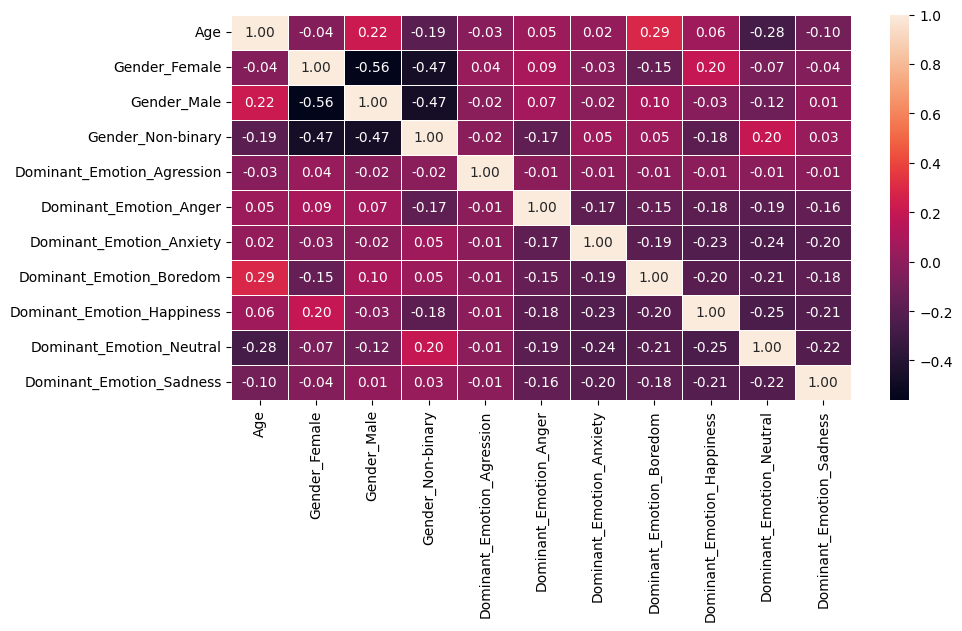

In [20]:
# Plot the correlation matrix
plt.figure(figsize=(10,5))
sns.heatmap(corre,annot=True,fmt=".2f", linewidth=.5)
plt.show()

In [21]:
# Bar Chart
chart1 = alt.Chart(hyp_data_new).mark_bar().encode(
    y='Dominant_Emotion',
    color = ('Gender'),
    x='count(Dominant_Emotion)'
).properties(height =300,width = 500, title='Distribution of Emotions among Social Media Users')
chart1.mark_bar(tooltip = True)

alt.Chart(...)

In [22]:
# Show the distribution of age among number of records using a Scatterplot
chart2 = alt.Chart(hyp_data_new).mark_circle().encode(
    x=alt.X('count(Dominant_Emotion)', scale=alt.Scale(zero=False)),
    color=alt.Color('Age', scale=alt.Scale(scheme = 'dark2')),
    y=alt.Y('Dominant_Emotion', scale=alt.Scale(zero=False))
).properties(height =300,width = 500, title='Distribution of Dominant Emotions among Users')
chart2.mark_circle(tooltip = True)

alt.Chart(...)

In [23]:
# Show the distribution of emotions among users from different genders using a Stacked Bar Chart
hyp_chart = alt.Chart(hyp_data_new).mark_bar().encode(
    y='Dominant_Emotion',
    x='count(Dominant_Emotion)'
).properties(
    height =500,width = 500,
    title='Distribution of Emotions among Social Media Users'
    )
hyp_chart.mark_bar(tooltip = True).encode(color = 'Age')

alt.Chart(...)

In [24]:
# Show the distribution of age among number of records using a Scatterplot
hyp_charttwo = alt.Chart(hyp_data_new).mark_circle().encode(
    x=alt.X('Dominant_Emotion', scale=alt.Scale(zero=False)),
    color=alt.Color('Age', scale=alt.Scale(scheme = 'yellowgreenblue')),
    y=alt.Y('count(Dominant_Emotion)', scale=alt.Scale(zero=False))
).properties(height =300,width = 500, title='Distribution of Emotions among Social Media Users')
hyp_charttwo.mark_circle(tooltip = True)

alt.Chart(...)

In [25]:
# Histogram
histogram = alt.Chart(hyp_data_new).mark_bar().encode(
    x = alt.X("Age:Q", bin=True),
    color = alt.Color('Dominant_Emotion'),
    y ='count()'
).properties(height =500,width = 300, title='Distribution of Emotions among Social Media Users')
histogram.mark_bar(tooltip = True)

alt.Chart(...)

In [ ]:
# Select rows of data where users are either male or female
new_data = data[((data['Gender'] == "Male") | (data['Gender'] == "Female"))]
new_data.head()

,User_ID,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion
0,1,25,Female,Instagram,120.0,3.0,45.0,10.0,12.0,Happiness
1,2,30,Male,Twitter,90.0,5.0,20.0,25.0,30.0,Anger
3,4,28,Female,Instagram,200.0,8.0,100.0,30.0,50.0,Anxiety
4,5,33,Male,LinkedIn,45.0,1.0,5.0,2.0,10.0,Boredom
5,6,21,Male,Instagram,150.0,4.0,60.0,15.0,25.0,Happiness


In [ ]:
base = alt.Chart(hyp_data_new).transform_calculate(
    gender=alt.expr.if_(alt.datum.sex == 1, 'Male', 'Female')
).properties(
    width=250
)


left = base.transform_filter(
    alt.datum.gender == 'Female'
).encode(
    x = alt.X('count(Dominant_Emotion)'),
    y = alt.Y('Age' , sort='descending'),
    color = alt.Color('Gender')
) .mark_bar().properties(title='Female')

middle = base.encode(
    y = alt.Y('Age',
    scale=alt.Scale(domain=(21,35))),
    text = alt.Text('Age'),
).mark_text().properties(width=20)

right = base.transform_filter(
    alt.datum.gender == 'Male'
).encode(
    x = alt.X('count(Dominant_Emotion)'),
    y = alt.Y('Age', sort='descending'),
    color = alt.Color('Gender')
).mark_bar().properties(title='Male')

pyramid = alt.concat(left, middle, right, spacing=5)
pyramid

alt.ConcatChart(...)

In [ ]:
base1 = alt.Chart(new_data).transform_calculate(
    gender=alt.expr.if_(alt.datum.sex == 1, 'Male', 'Female')
).properties(
    width=250
)

middle1 = base.encode(
    y = alt.Y('Age'),
    text = alt.Text('Age'),
).mark_text().properties(width=20)

index = ['Age',	'Gender',	'Dominant_Emotion']

chart_m = alt.Chart(new_data).mark_bar().encode(
    x=alt.X('count(Dominant_Emotion):Q',
            title='Male',
            sort='ascending',
            scale=alt.Scale(domain=(0,100))),
    y=alt.Y('Age', axis=alt.Axis(title='Age Groups'), sort='descending'),
    color=alt.Color('Age')
)

chart_f = alt.Chart(new_data).mark_bar().encode(
    x=alt.X('count(Dominant_Emotion):Q',
            title='Female',
            sort='ascending',
            scale=alt.Scale(domain=(0,100))),
    y=alt.Y('Age', axis=None, sort='descending'),
    color=alt.Color('Age')
)

#chart_m | chart_f
alt.concat(chart_m, middle1, chart_f, spacing=5)

alt.ConcatChart(...)

In [ ]:
# Select rows of data where users are either male or female
new_dataF = data[(hyp_data_new['Gender'] == "Female")]
new_dataM = data[(hyp_data_new['Gender'] == "Male")]

base2 = alt.Chart(new_data).transform_calculate(
    gender=alt.expr.if_(alt.datum.sex == 1, 'Male', 'Female')
).properties(
    width=250
)

left2 = alt.Chart(new_dataF).encode(
    x = alt.X('count(Dominant_Emotion)'),
    y = alt.Y('Age' , sort='ascending'),
    color = alt.Color('Gender', scale=alt.Scale(range=['#e377c2','#1f77b4']))
) .mark_bar().properties(width=250, title='Female')

middle2 = base2.encode(
    y = alt.Y('Age',
    scale=alt.Scale(domain=(21,35))),
    text = alt.Text('Age'),
).mark_text().properties(width=20)

right2 = alt.Chart(new_dataM).encode(
    x = alt.X('count(Dominant_Emotion)'),
    y = alt.Y('Age'),
    color = alt.Color('Gender' , scale=alt.Scale(range=['#e377c2','#1f77b4']))
).mark_bar().properties(width=250, title='Male')

pyramid2 = alt.concat(left2, middle2, right2, spacing=5)
pyramid2

alt.ConcatChart(...)

In [ ]:
# Show the distribution of age among number of records using a Scatterplot
hyp_chart2 = alt.Chart(hyp_data_new).mark_circle().encode(
    x=alt.X('Age', scale=alt.Scale(zero=False)),
    color=alt.Color('Age', scale=alt.Scale(scheme = 'dark2')),
    y=alt.Y('count(Age)', scale=alt.Scale(zero=False))
).properties(height =300,width = 500, title='Distribution of Number of Social Media Users by Age')
hyp_chart2.mark_circle(tooltip = True)

alt.Chart(...)

In [ ]:
# use value_counts() to count occurrences of different genders
f = hyp_data_new['Gender'].value_counts()['Female']
m = hyp_data_new['Gender'].value_counts()['Male']
n = hyp_data_new['Gender'].value_counts()['Non-binary']

# gender dataframe
gender_df = pd.DataFrame({"Gender": genders, "Count": [f,m,n]})

gender_pie = alt.Chart(gender_df).mark_arc().encode(
    theta="Count",
    color="Gender"
).properties(height =300,width = 500, title='Percentage Distribution of Social Media Users Gender ')
gender_pie.mark_arc(tooltip = True)

alt.Chart(...)

## End of New Stuff for Midterm Presentation

### Female < 30

***The most common dominant emotion among female social media users under 30 years old is anxiety.***

In [ ]:
# Select rows of data where users are female and younger than 30 years old
hyp1_data = data[((data['Age'] < 30) & (data['Gender'] == "Female"))]
hyp1_data.head()


,User_ID,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion
0,1,25,Female,Instagram,120.0,3.0,45.0,10.0,12.0,Happiness
3,4,28,Female,Instagram,200.0,8.0,100.0,30.0,50.0,Anxiety
6,7,27,Female,Twitter,85.0,3.0,30.0,10.0,18.0,Anger
8,9,29,Female,LinkedIn,55.0,2.0,10.0,3.0,8.0,Neutral
10,11,23,Female,Twitter,75.0,4.0,35.0,7.0,20.0,Anxiety


In [ ]:
# Copy age, platform, daily usage and dominant emotion columns to a new dataframe
hyp1_data_new = pd.DataFrame()
hyp1_data_new['Age'] = hyp1_data['Age'].copy()
hyp1_data_new['Platform'] = hyp1_data['Platform'].copy()
hyp1_data_new['Daily_Usage_Time (minutes)'] = hyp1_data['Daily_Usage_Time (minutes)'].copy()
hyp1_data_new['Dominant_Emotion'] = hyp1_data['Dominant_Emotion'].copy()

hyp1_data_new.reset_index(drop=True).head()


,Age,Platform,Daily_Usage_Time (minutes),Dominant_Emotion
0,25,Instagram,120.0,Happiness
1,28,Instagram,200.0,Anxiety
2,27,Twitter,85.0,Anger
3,29,LinkedIn,55.0,Neutral
4,23,Twitter,75.0,Anxiety


In [ ]:
# One-hot encodings of nominal variables
hyp1Data_OneHot = pd.get_dummies(hyp1_data_new)
hyp1Data_OneHot.head()


,Age,Daily_Usage_Time (minutes),Platform_Facebook,Platform_Instagram,Platform_LinkedIn,Platform_Snapchat,Platform_Twitter,Platform_Whatsapp,Dominant_Emotion_Agression,Dominant_Emotion_Anger,Dominant_Emotion_Anxiety,Dominant_Emotion_Boredom,Dominant_Emotion_Happiness,Dominant_Emotion_Neutral,Dominant_Emotion_Sadness
0,25,120.0,False,True,False,False,False,False,False,False,False,False,True,False,False
3,28,200.0,False,True,False,False,False,False,False,False,True,False,False,False,False
6,27,85.0,False,False,False,False,True,False,False,True,False,False,False,False,False
8,29,55.0,False,False,True,False,False,False,False,False,False,False,False,True,False
10,23,75.0,False,False,False,False,True,False,False,False,True,False,False,False,False


In [ ]:
# Find the pearson correlations matrix
corr = hyp1Data_OneHot.corr(method = 'pearson')
corr.head()


,Age,Daily_Usage_Time (minutes),Platform_Facebook,Platform_Instagram,Platform_LinkedIn,Platform_Snapchat,Platform_Twitter,Platform_Whatsapp,Dominant_Emotion_Agression,Dominant_Emotion_Anger,Dominant_Emotion_Anxiety,Dominant_Emotion_Boredom,Dominant_Emotion_Happiness,Dominant_Emotion_Neutral,Dominant_Emotion_Sadness
Age,1.000000,-0.035772,-0.243055,-0.236246,0.328432,0.299655,-0.223756,0.209332,-0.024018,0.116184,0.024073,0.193929,-0.045549,0.073383,-0.263828
Daily_Usage_Time (minutes),-0.035772,1.000000,-0.214186,0.808063,-0.373861,-0.004840,-0.362198,-0.210710,0.044359,-0.207349,0.040752,-0.258542,0.560779,-0.218223,-0.155663
Platform_Facebook,-0.243055,-0.214186,1.000000,-0.157963,-0.066431,-0.083862,-0.133491,-0.087340,-0.012259,-0.091882,-0.069840,-0.043210,-0.132442,0.366447,-0.053459
Platform_Instagram,-0.236246,0.808063,-0.157963,1.000000,-0.216169,-0.272890,-0.434385,-0.284208,0.077608,-0.298989,-0.133370,-0.140606,0.646551,-0.163860,-0.107806
Platform_LinkedIn,0.328432,-0.373861,-0.066431,-0.216169,1.000000,-0.114763,-0.182679,-0.119523,-0.016777,-0.094304,-0.146673,0.591312,-0.181244,0.239350,-0.097887


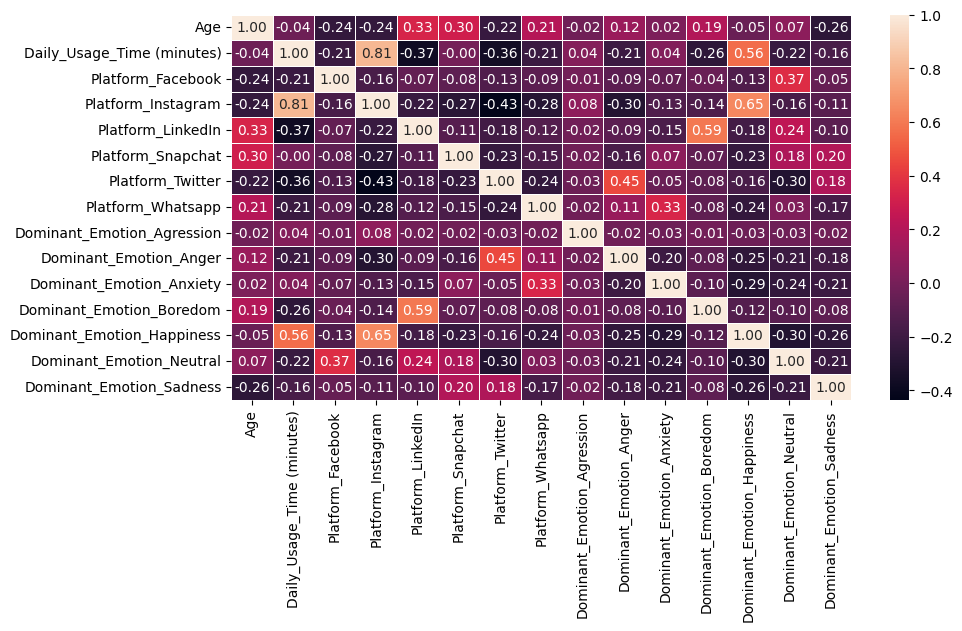

In [ ]:
# Plot the correlation matrix
plt.figure(figsize=(10,5))
sns.heatmap(corr,annot=True,fmt=".2f", linewidth=.5)
plt.show()


### 4.1.2 Visualization

#### **First Attempt**

In [ ]:
# Show the distribution of emotions among females under 30 using a Bar Chart
hyp1_chart1 = alt.Chart(hyp1_data_new).mark_bar().encode(
    x='Dominant_Emotion',
    color=('Age'),
    y='count(Dominant_Emotion)'
).properties(height =300,width = 500, title='Distribution of Dominant Emotions among Female Social Media Users')
hyp1_chart1


alt.Chart(...)

***What's informative about this view:*** This view shows the distribution of dominant emotions among female social media users. This is helpful to identify the least and most common emotion expressed in this subset of the dataset.

***What could be improved about this view:***  Even though this view is informative, it is missing the age attribute which would help to either support or reject hypothesis #1.


#### **Second Attempt**

In [ ]:
# Show the distribution of emotions among females under 30 using a Scatterplot
hyp1_chart2 = alt.Chart(hyp1_data_new).mark_circle().encode(
    x=alt.X('Dominant_Emotion', scale=alt.Scale(zero=False)),
    color=alt.Color('Age', scale=alt.Scale(scheme = 'dark2')),
    y=alt.Y('count(Dominant_Emotion)', scale=alt.Scale(zero=False))
).properties(height =300,width = 500, title='Relationship between Dominant Emotions and Age among Female Social Media Users')
hyp1_chart2


alt.Chart(...)

***What's informative about this view:*** This view shows the correlation between emotions and the number of female social media users who express those emotions based on their age.

***What could be improved about this view:*** It is difficult to pinpoint which emotion is the most common among the female social users based on their age.

#### **Third Attempt**

In [ ]:
# Show the distribution of emotions among females under 30 using a Stacked Bar Chart
hyp1_chart3 = alt.Chart(hyp1_data_new).mark_bar().encode(
    x='Dominant_Emotion',
    y='count(Dominant_Emotion)'
).properties(
    height =500,width = 500,
    title='Distribution of Dominant Emotions among Female Social Media Users under 30 '
    )
hyp1_chart3.mark_bar(tooltip = True).encode(color = 'Age')


alt.Chart(...)

***What's informative about this view:*** This visualization shows which emotion is manifested among a certain number of female social media users based on their age. The granularity showcased in this view helps with specificity.  



### 4.1.3 Conclusion

 The correlation coefficient between age and anxiety is 0.04. This indicates no linear relationship between these attributes. Through the resulting visualizations, one can observe that anxiety is a prevalent emotion. However, anxiety is not the most common dominant emotion expressed by female social media users under 30 years old in this dataset. This is evidence against hypothesis #1. Therefore, this null hypothesis is rejected.

### Male < 30

In [ ]:
# Select rows of data where users are male and younger than 30 years old
males = hyp_data_new[((hyp_data_new['Age'] < 30) & (hyp_data_new['Gender'] == "Male"))]
males.head()

,Age,Gender,Dominant_Emotion
5,21,Male,Happiness
14,28,Male,Anger
17,27,Male,Sadness
20,26,Male,Anxiety
22,29,Male,Boredom


In [ ]:
# Show the distribution of emotions among males under 30 using a Stacked Bar Chart
males_chart3 = alt.Chart(males).mark_bar().encode(
    x='Dominant_Emotion',
    y='count(Dominant_Emotion)'
).properties(
    height =500,width = 500,
    title='Distribution of Dominant Emotions among Male Social Media Users under 30 '
    )
males_chart3.mark_bar(tooltip = True).encode(color = 'Age')

alt.Chart(...)

### Non-binary < 30

In [ ]:
# Select rows of data where users are female and younger than 30 years old
non_binaries = hyp_data_new[((hyp_data_new['Age'] < 30) & (hyp_data_new['Gender'] == "Non-binary"))]
non_binaries.head()

,Age,Gender,Dominant_Emotion
2,22,Non-binary,Neutral
7,24,Non-binary,Sadness
11,26,Non-binary,Sadness
15,21,Non-binary,Neutral
18,23,Non-binary,Neutral


In [ ]:
# Show the distribution of emotions among non-binary users under 30 using a Stacked Bar Chart
non_binaries_chart3 = alt.Chart(non_binaries).mark_bar().encode(
    x='Dominant_Emotion',
    y='count(Dominant_Emotion)'
).properties(
    height =500,width = 500,
    title='Distribution of Dominant Emotions among Non-binary Social Media Users under 30 '
    )
non_binaries_chart3.mark_bar(tooltip = True).encode(color = 'Age')

alt.Chart(...)

## Example of drop down menu

In [1]:
import altair as alt
from vega_datasets import data

source = data.stocks()
source.symbol.value_counts()


source["category"] = "category_1"
source.loc[source["symbol"].isin(["AMZN", "IBM"]), "category"] = "category_2"


dropdown_category = alt.binding_select(options=list(source["category"].unique()), name=" ")
dropdown_symbol = alt.binding_select(options=list(source["symbol"].unique()), name=" ")

selection_category = alt.selection_single(fields=["category"], bind=dropdown_category)
selection_symbol = alt.selection_single(fields=["symbol"], bind=dropdown_symbol)

chart = alt.Chart(source).mark_line().encode(
    x='date',
    y='price',
    color='symbol',
    opacity=alt.condition(
        selection_category & selection_symbol,
        alt.value(1),
        alt.value(0.1)
)).add_selection(selection_symbol, selection_category)

chart

alt.Chart(...)

In [3]:
source

,symbol,date,price,category
0,MSFT,2000-01-01,39.81,category_1
1,MSFT,2000-02-01,36.35,category_1
2,MSFT,2000-03-01,43.22,category_1
3,MSFT,2000-04-01,28.37,category_1
4,MSFT,2000-05-01,25.45,category_1
...,...,...,...,...
555,AAPL,2009-11-01,199.91,category_1
556,AAPL,2009-12-01,210.73,category_1
557,AAPL,2010-01-01,192.06,category_1
558,AAPL,2010-02-01,204.62,category_1


## Example of slider

In [27]:
import pandas as pd
import numpy as np

rand = np.random.RandomState(42)

df = pd.DataFrame({
    'xval': range(100),
    'yval': rand.randn(100).cumsum()
})

slider = alt.binding_range(min=0, max=100, step=1, name='cutoff:')
selector = alt.selection_single(name="SelectorName", fields=['cutoff'],
                                bind=slider, init={'cutoff': 50})

alt.Chart(df).mark_point().encode(
    x='xval',
    y='yval',
    color=alt.condition(
        alt.datum.xval < selector.cutoff,
        alt.value('red'), alt.value('blue')
    )
).add_selection(
    selector
)

alt.Chart(...)

## Final Chart

In [ ]:
# Select rows of data where users are either male or female
new_data = data[((data['Gender'] == "Male") | (data['Gender'] == "Female"))]
new_data.head()

# Select rows of data where users are female and younger than 30 years old
hyp1_data = data[((data['Age'] < 30) & (data['Gender'] == "Female"))]
hyp1_data.head()

In [36]:
# Base chart
base = alt.Chart(hyp_data_new).mark_bar().encode(
    y='Dominant_Emotion',
    x='count(Dominant_Emotion)'
).properties(
    height =500,width = 500,
    title='Distribution of Emotions among Social Media Users'
    )
base.mark_bar(tooltip = True).encode(color = 'Age')

alt.Chart(...)

### update altair version

In [39]:
!pip install -U altair

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.8/857.8 kB 7.8 MB/s eta 0:00:00
  Attempting uninstall: altair
    Found existing installation: altair 4.2.2
    Uninstalling altair-4.2.2:
      Successfully uninstalled altair-4.2.2


In [44]:
# A slider filter
age_slider = alt.binding_range(min=21, max=35, step=1, name="Age")
slider_selection = alt.selection_single(bind=age_slider, fields=['Age'])

filter_age = alt.Chart(hyp_data_new).mark_bar().encode(
    y='Dominant_Emotion',
    x='count(Dominant_Emotion)'
).properties(
    height =500,width = 500,
    title='Distribution of Emotions among Social Media Users'
).add_selection(
    slider_selection
).transform_filter(
    slider_selection
).properties(title="Slider Filtering")
filter_age.mark_bar(tooltip = True).encode(color = 'Age')

alt.Chart(...)

In [47]:
# A dropdown filter
gender_dropdown = alt.binding_select(options=genders, name="Gender")
gender_select = alt.selection_single(fields=['Gender'], bind=gender_dropdown)

filter_genders = alt.Chart(hyp_data_new).mark_bar().encode(
    y='Dominant_Emotion',
    x='count(Dominant_Emotion)'
).properties(
    height =500,width = 500,
    title='Distribution of Emotions among Social Media Users'
).add_selection(
    gender_select
).transform_filter(
    gender_select
).properties(title="Dropdown Filtering")
filter_genders.mark_bar(tooltip = True).encode(color = 'Age')

alt.Chart(...)

In [50]:
filter_age.mark_bar(tooltip = True).encode(color = 'Age')| filter_genders.mark_bar(tooltip = True).encode(color = 'Age')

alt.HConcatChart(...)

In [49]:
hyp_data_new.head(10)

,Age,Gender,Dominant_Emotion
0,25,Female,Happiness
1,30,Male,Anger
2,22,Non-binary,Neutral
3,28,Female,Anxiety
4,33,Male,Boredom
5,21,Male,Happiness
6,27,Female,Anger
7,24,Non-binary,Sadness
8,29,Female,Neutral
9,31,Male,Happiness


In [34]:
# Show the distribution of emotions among users from different genders using an interactive Stacked Bar Chart

# Slider
slider = alt.binding_range(min=21, max=35, step=1, name='Age:')
selector = alt.selection_single(name="SelectorName", fields=['Age'],
                                bind=slider, init={'Age': 30})

final_chart = alt.Chart(hyp_data_new).mark_bar().encode(
    y='Dominant_Emotion',
    x='count(Dominant_Emotion)',
    color=alt.condition(
        alt.datum.xval < selector.Age,
        alt.value('red'), alt.value('blue'))
).properties(
    height =500,width = 500,
    title='Distribution of Emotions among Social Media Users'
).add_selection(
    selector
)
final_chart #.mark_bar(tooltip = True).encode(color = 'Age')

alt.Chart(...)

## **4.3 Hypothesis #3**

***Increased duration of social media usage can be correlated with higher levels of negative emotions, such as anxiety. Conversely, decrease in social media usage is posited to be associated with feelings of boredom.***





### 4.3.1 Inspect Data and Investigating

In [ ]:
# look at distribution of time
print(data['Daily_Usage_Time (minutes)'].describe())

print()

# looking at the distribution for dominate emotions
print(data['Dominant_Emotion'].describe())


count    1248.000000
mean       95.243590
std        38.951823
min        30.000000
25%        65.000000
50%        85.000000
75%       120.000000
max       200.000000
Name: Daily_Usage_Time (minutes), dtype: float64

count        1248
unique          7
top       Neutral
freq          258
Name: Dominant_Emotion, dtype: object


In [ ]:
hyp_3_data = data.copy()

# one hot encoding the categorical emotions
one_hot_encode_emotion = pd.get_dummies(hyp_3_data['Dominant_Emotion'], prefix = 'Emotion')
one_hot_encode_emotion = one_hot_encode_emotion.astype(int)
hyp_3_data = pd.concat([hyp_3_data, one_hot_encode_emotion], axis = 1)
hyp_3_data.head(5)


,User_ID,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion,Emotion_Agression,Emotion_Anger,Emotion_Anxiety,Emotion_Boredom,Emotion_Happiness,Emotion_Neutral,Emotion_Sadness
0,1,25,Female,Instagram,120.0,3.0,45.0,10.0,12.0,Happiness,0,0,0,0,1,0,0
1,2,30,Male,Twitter,90.0,5.0,20.0,25.0,30.0,Anger,0,1,0,0,0,0,0
2,3,22,Non-binary,Facebook,60.0,2.0,15.0,5.0,20.0,Neutral,0,0,0,0,0,1,0
3,4,28,Female,Instagram,200.0,8.0,100.0,30.0,50.0,Anxiety,0,0,1,0,0,0,0
4,5,33,Male,LinkedIn,45.0,1.0,5.0,2.0,10.0,Boredom,0,0,0,1,0,0,0


In [ ]:
# creating correlation matrix between time spent on social media vs emotions

# selecting emotions and time usage coloumn
emotion_columns = [col for col in hyp_3_data.columns if col.startswith('Emotion')]
columns_for_correlation = emotion_columns + ['Daily_Usage_Time (minutes)']

correlatiton_matrix_df = hyp_3_data[columns_for_correlation]

correlation_matrix = correlatiton_matrix_df .corr()
correlation_matrix.head()


,Emotion_Agression,Emotion_Anger,Emotion_Anxiety,Emotion_Boredom,Emotion_Happiness,Emotion_Neutral,Emotion_Sadness,Daily_Usage_Time (minutes)
Emotion_Agression,1.000000,-0.010506,-0.013245,-0.011398,-0.013854,-0.014456,-0.012334,0.032551
Emotion_Anger,-0.010506,1.000000,-0.173524,-0.149334,-0.181501,-0.189399,-0.161594,-0.045105
Emotion_Anxiety,-0.013245,-0.173524,1.000000,-0.188255,-0.228806,-0.238763,-0.203710,-0.010970
Emotion_Boredom,-0.011398,-0.149334,-0.188255,1.000000,-0.196909,-0.205478,-0.175312,-0.317992
Emotion_Happiness,-0.013854,-0.181501,-0.228806,-0.196909,1.000000,-0.249739,-0.213075,0.683130


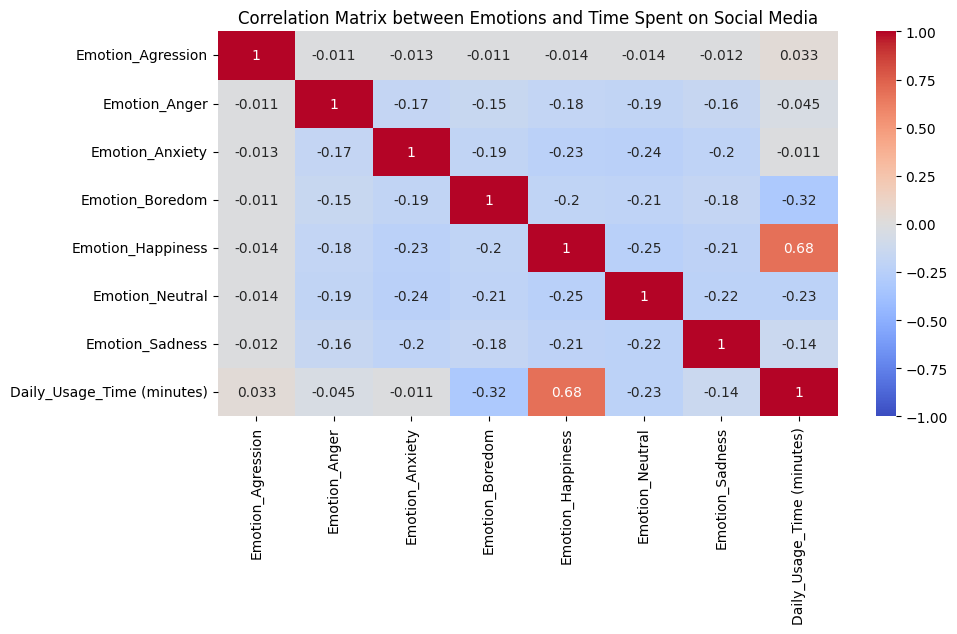

In [ ]:
plt.figure(figsize=(10, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix between Emotions and Time Spent on Social Media')
plt.show()


### 4.3.2 Visualizaton

#### **First Attempt**

In [ ]:
# graphing a line chart of dominate emotions in relation to duration of time spent on social media
line_chart = alt.Chart(data).mark_line().encode(
    x = 'Daily_Usage_Time (minutes)',
    y = 'Dominant_Emotion',
    color = 'Dominant_Emotion',
). properties(
    title = 'Dominate Emotions in Relation to Time Spent on Social Media ',
    width = 600,
    height = 350
)

line_chart


alt.Chart(...)

#### **Second Attempt**

In [ ]:
source = hyp_3_data[['Daily_Usage_Time (minutes)', 'Dominant_Emotion']]

step = 10
overlap = 1.5

emotion_colors = {
    'Happiness':'#f6be59',
    'Anger':'#db5247',
    'Agression':'#c43141',
    'Neutral':'#c4a293',
    'Anxiety':'#8a55a6',
    'Boredom':'#cbd1d4',
    'Sadness':'#b2cae1'
}
second_chart = alt.Chart(source, height=step).transform_bin(
    ['bin_max', 'bin_min'], 'Daily_Usage_Time (minutes)', bin=alt.Bin(maxbins=20)
).transform_aggregate(
    value='count()', groupby=['Dominant_Emotion', 'bin_min', 'bin_max']
).transform_impute(
    impute='value', groupby=['Dominant_Emotion'], key='bin_min', value=0
).mark_area(
    interpolate='monotone',
    fillOpacity=0.8,
    stroke='lightgray',
    strokeWidth=0.5
).encode(
    alt.X('bin_min:Q', bin='binned', title='Daily Usage Time (minutes)'),
    alt.Y(
        'value:Q',
        scale=alt.Scale(range=[step, -step * overlap]),
        axis=None
    ),
    alt.Color(
        'Dominant_Emotion:N',
        legend=None,
        scale=alt.Scale(
            domain=list(emotion_colors.keys()),
            range=list(emotion_colors.values())
        )
    )
).facet(
    row=alt.Row(
        'Dominant_Emotion:N',
        title=None,
        header=alt.Header(labelAngle=0, labelAlign='left')
    )
).properties(
    title='Correlation Between Daily Usage Time and Dominant Emotions',
    bounds='flush'
).configure_facet(
    spacing=0
).configure_view(
    stroke=None
).configure_title(
    anchor='end'
)

second_chart



alt.FacetChart(...)

#### **Third Attempt**

In [ ]:
source = hyp_3_data[['Daily_Usage_Time (minutes)', 'Dominant_Emotion']]


emotion_colors = {
    'Happiness': '#f6be59',
    'Anger': '#df745e',
    'Agression': '#c43141',
    'Neutral': '#c4a293',
    'Anxiety': '#8a55a6',
    'Boredom': '#cbd1d4',
    'Sadness': '#b2cae1'
}

emotion_order = ['Happiness', 'Neutral', 'Boredom', 'Anxiety', 'Sadness', 'Anger', 'Agression']

binned_data = source.copy()
binned_data['bin'] = pd.cut(binned_data['Daily_Usage_Time (minutes)'], bins=20)
binned_data = binned_data.groupby(['Dominant_Emotion', 'bin']).size().reset_index(name='count')

binned_data['bin_start'] = binned_data['bin'].apply(lambda x: x.left)
binned_data['bin_end'] = binned_data['bin'].apply(lambda x: x.right)

third_chart = alt.Chart(source).transform_density(
    density='Daily_Usage_Time (minutes)',
    bandwidth=5,
    groupby=['Dominant_Emotion'],
    extent=[0, 200]
).mark_area().encode(
    alt.X('value:Q', title='Daily Usage Time (minutes)'),
    alt.Y('density:Q', title='Density'),
    alt.Row('Dominant_Emotion:N', title='Emotions', sort=emotion_order),
    alt.Color('Dominant_Emotion:N', scale=alt.Scale(domain=list(emotion_colors.keys()), range=list(emotion_colors.values())), legend=alt.Legend(title="Dominant Emotions")),
    tooltip=[alt.Tooltip('value:Q', title='Time (minutes)'),
             alt.Tooltip('density:Q', title='Density'),
             alt.Tooltip('Dominant_Emotion:N', title='Emotion')]


).properties(
    width=300,
    height=50,
    title='Correlation between Daily Usage Time and Dominant Emotions'
).configure_title(
    anchor='middle'
)


third_chart.display()


alt.Chart(...)

#### **Fourth Attempt**

In [ ]:
source = hyp_3_data[['Daily_Usage_Time (minutes)', 'Dominant_Emotion']]

emotion_colors = {
    'Happiness': '#f6be59',
    'Anger': '#df745e',
    'Agression': '#c43141',
    'Neutral': '#c4a293',
    'Anxiety': '#8a55a6',
    'Boredom': '#cbd1d4',
    'Sadness': '#b2cae1'
}

emotion_order = ['Happiness', 'Neutral', 'Boredom', 'Anxiety', 'Sadness', 'Anger', 'Agression']

scale = alt.Scale(domain=list(emotion_colors.keys()), range=list(emotion_colors.values()))
color = alt.Color('Dominant_Emotion:N', scale=scale)


brush = alt.selection_interval(encodings=['x'])
click = alt.selection_multi(encodings=['color'])


circle = alt.Chart(source).mark_circle().encode(
    alt.Y('Dominant_Emotion:N', title='Dominant Emotion', sort=emotion_order),
    alt.X('Daily_Usage_Time (minutes):Q', title='Daily Usage Time (minutes)'),
    color=alt.condition(brush, color, alt.value('lightgray')),
    size=alt.value(100)
).properties(
    width=550,
    height=300
).add_selection(
    brush
).transform_filter(
    click
)


bars = alt.Chart(source).mark_bar().encode(
    x='count()',
    y=alt.Y('Dominant_Emotion:N', title='Dominant Emotion', sort=emotion_order),
    color=alt.condition(click, color, alt.value('lightgray')),
).transform_filter(
    brush
).properties(
    width=550,
).add_selection(
    click
)

forth_chart = alt.vconcat(
    circle,
    bars,
    title="Daily Usage Time and its Relationship to Dominant Emotion"
).configure_title(
    anchor='middle',
    fontSize = 15

)

forth_chart.display()


alt.VConcatChart(...)